# **IS4487 Module 9 - Practice/Demo code**

This notebook is designed to help you follow along with the **Module 9 Lecture and Reading**, introducing you to segmentation through clustering.

The practice code demos are intended to give you a chance to see working code and can be a source for your lab and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Use K-Means Clustering for Segmentation
- Plot the results

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_09_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Context: Customer Segmentation
We will use a simple dataset using the following retail shopper characteristics

| Feature     | Description                                          | Type        |
| ----------- | ---------------------------------------------------- | ----------- |
| `visits`       | Number of visits in the last 2 years        | Numeric     |
| `spending`   | Total amount spent in the last 2 years           | Numeric |
| `annual income`   | Annual income in thousands of dollars             | Numeric     |
| `customer ID`   | customer ID number                        | Numeric |

There is no target variable!  You will be grouping the customers

### **K-Means Clustering**

K-Means is an **unsupervised learning** algorithm that groups data into **k** clusters by minimizing the distance between points and their cluster’s center (centroid).

### How it works?
It starts by randomly selecting k centroids, then iteratively assigns points to the nearest centroid and updates centroids until the solution stabilizes.

### Where is it used?
Unsupervised learning is often used in descriptive and diagnostic analytics. It is not considered as predictive analytics/modeling. Supervised learning requires labeled data (dataset where we know the target's true/actual values for some of the observations).

## Step 1: Load libraries, create sample demo data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Sample customer data
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'Spending': [300, 450, 290, 1600, 1700, 1720, 700, 500, 900, 1000, 705, 790, 410, 520, 850],
    'Visits': [3,4,3,16,17,17,7,5,8,9,7,8,4,5,9],
    'Annual Income (k$)': [60, 82, 85, 220, 200, 210, 150, 142, 180, 205, 144, 160, 80, 104, 145]
}


# Create DataFrame
df = pd.DataFrame(data)

## Step 2: Prepare Data

Before applying k-means, we need to prepare the data. K-means is a distance-based algorithm, so it is good to have the features used for clustering be of similar scale. You can choose normalization or standardization for this.

In [16]:
# select a subset of features to use for clustering
X = df[['Annual Income (k$)', 'Spending', 'Visits']]

# Scale features by standardizing them
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 3: Create Model

In this step, we will initialize the model and apply it.
The command to apply the model is `model.fit_predict()`. This does two things: **fit** and **predict**.

The **fit** step learns the patterns and association in data first. Then **predict** step will produce the output of the model - the group ID. In this case, we are NOT making a prediction; rather we are determining the hidden underlying grouping of observations.

In [17]:
# Initialize the model - we ask for 3 clusters, and give it a random starting seed = 42
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit and obtain the output of the model - group ID stored in column cluster.
df['Cluster'] = kmeans.fit_predict(X_scaled)

## Step 4: Visualize Model

In [18]:
# View the groups produced in the output of k-means
df['Cluster'].value_counts()

,count
Cluster,
2,7
1,5
0,3


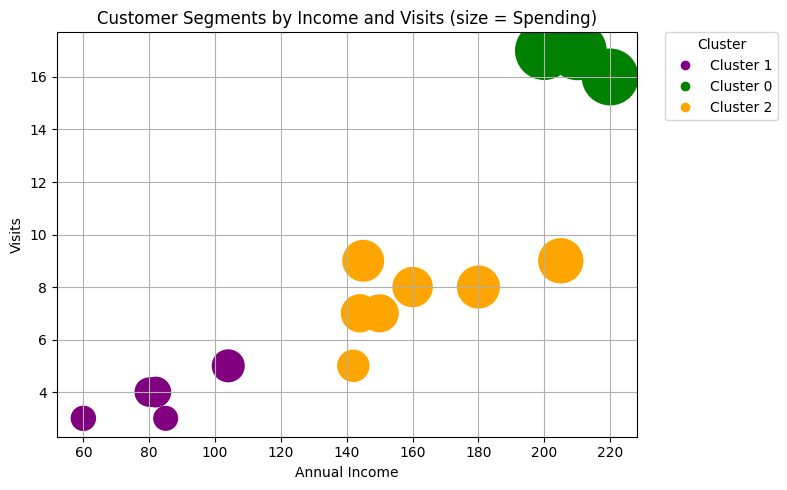

In [49]:
from matplotlib.lines import Line2D

# choose colors to use for each cluster
colors = ['purple', 'green', 'orange']

# plot each cluster one by one
plt.figure(figsize=(8,5))
for i, cluster in enumerate(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['Annual Income (k$)'], subset['Visits'], s=subset['Spending'], color=colors[i], label=f'Cluster {cluster}')

plt.xlabel('Annual Income')
plt.ylabel('Visits')
plt.title('Customer Segments by Income and Visits (size = Spending)')

# --- Custom legend with uniform marker size ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}', markerfacecolor=colors[i], markersize=8) for i, cluster in enumerate(df['Cluster'].unique()) ]
plt.legend( handles=legend_elements, title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.grid(True)
plt.tight_layout()
plt.show()

### Visualize Model Again with Centroids

Let us replot the above chart, but this time we will draw the cluster spheres and their centroid.

Please note: While k-means tries to creates spherical clusters of similar size, the spheres will be drawn as ellipses because the scale of the variables on the two axes are very different in the raw data.

Dont worry about the code - this is just for demonstration.

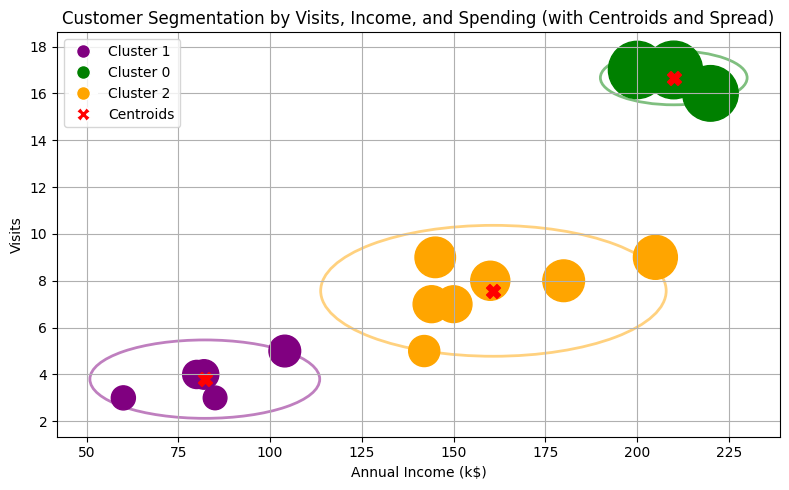

In [53]:
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

# Plot clusters in a chart of Visits (Y) vs Annual Income (X)
plt.figure(figsize=(8, 5))
ax = plt.gca() # Get the current axes for adding patches

# Get the unique clusters
unique_clusters = df['Cluster'].unique()
# choose colors to use for each cluster
colors = ['purple', 'green', 'orange']


# Plot data points with size representing spending
for i, cluster in enumerate(unique_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Visits'], s=cluster_data['Spending'], label=f'Cluster {cluster}', color=colors[i])

    # Calculate the center and standard deviation for each cluster
    center_x = cluster_data['Annual Income (k$)'].mean()
    center_y = cluster_data['Visits'].mean()
    std_x = cluster_data['Annual Income (k$)'].std()
    std_y = cluster_data['Visits'].std()

    # Create an ellipse patch representing the spread (e.g., 2 standard deviations)
    # Angle is 0 because we are not rotating based on covariance
    ellipse = Ellipse((center_x, center_y), width=std_x * 4, height=std_y * 4,
                      edgecolor=colors[i], fc='None', lw=2, alpha=0.5)
    ax.add_patch(ellipse)

# Get the centroids from the fitted KMeans model
# We need to inverse transform them to the original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot centroids
# Note: Centroids are in the order of the clusters as they appear in unique_clusters if they were sorted,
# but since we are iterating through unique_clusters and using the index i, the colors will match.
plt.scatter(centroids[:, 0], centroids[:, 2], marker='X', s=100, color='red', label='Centroids')


# Create a custom legend with fixed marker size and matching colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}',
                          markerfacecolor=colors[i], markersize=10)
                   for i, cluster in enumerate(unique_clusters)]

# Add the centroid marker to the legend elements
legend_elements.append(Line2D([0], [0], marker='X', color='w', label='Centroids',
                              markerfacecolor='red', markersize=10))


plt.xlabel('Annual Income (k$)')
plt.ylabel('Visits')
plt.title('Customer Segmentation by Visits, Income, and Spending (with Centroids and Spread)')
plt.legend(handles=legend_elements)
plt.grid(True)
plt.tight_layout()
plt.show()